In [ ]:
# ..... get paralog substituion events including ancient paralogs ..... #
# across all primate clusters x primate clusters 
# just the no. of shared and paralog markers

In [2]:
library(data.table)
library(dplyr)
library(ggplot2)

In [3]:
# get no. of paralogs between two vectors
get_paralog_count <- function(vec1, vec2, pmat){
    mat1 = data.frame(g1 = rep(vec1, each = length(vec2)), 
                      g2 = rep(vec2, length(vec1)), paralog = NA)
    glist = paste0(mat1[,1], '_', mat1[,2])
    mat1$paralog = !is.na(match(glist, pmat))
    temp = mat1 %>% group_by(g1) %>% summarise(n = sum(paralog))
    return(temp)
}

In [4]:
# get list of paralogs 
tab1 = read.delim('/vault/suresh/consensus_interneuron_taxonomy/homologs/human_paralogs.txt', sep = '\t')
tab1 <- tab1[(tab1[,1]!='' & tab1[,2]!='' & tab1[,4]!='' & tab1[,4]!='gene_split'),]
tab1 <- tab1[!duplicated(tab1),]
colnames(tab1)[1:2] = c('sp1_gene', 'sp2_gene')

# human - NHP
paralog_df1 = paste0(unlist(tab1$sp1_gene), '_', unlist(tab1$sp2_gene))

# NHP - human
paralog_df2 = paralog_df1

head(paralog_df1)

[1] "MT-ND2_MT-ND4" "MT-ND2_MT-ND5" "MT-ND4_MT-ND5" "MT-ND4_MT-ND2"
[5] "MT-ND5_MT-ND4" "MT-ND5_MT-ND2"

In [4]:
# species in Ma et al
spelist1 = c('human', 'chimp', 'macaque', 'marmoset')

# species in Caglayan et al
spelist2 = c('human', 'chimp', 'macaque')

In [5]:
currstudy = 'caglayan'

if(currstudy=='sestan'){
    spe_combos = combn(spelist1, 2)
}else{
    spe_combos = combn(spelist2, 2)
}
spe_combos

human,human,chimp
chimp,macaque,macaque


In [8]:
# get marker lists
currid = 2
sp1 = spe_combos[1,currid]
sp2 = spe_combos[2,currid]

tab2 = fread(paste0(currstudy, '_', sp1, '_de_novo_cluster_markers.csv.gz'))
ctypes2 = unique(tab2$cell_type)
tab2[1:2,]

tab3 = fread(paste0(currstudy, '_', sp2, '_de_novo_cluster_markers.csv.gz'))
ctypes3 = unique(tab3$cell_type)
tab3[1:2,]

group,cell_type,gene,fold_change,auroc,log_fdr,population_size,population_fraction,average_expression,se_expression,detection_rate,fold_change_detection,precision,recall
<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all,0,SLC9A9,5.053983,0.9123337,-847.7477,930,0.09755586,1233.113,21.92533,0.9784946,2.544566,0.2159981,0.9784946
all,0,TMEM132C,4.642661,0.9079881,-830.4813,930,0.09755586,1234.742,21.06647,0.9881720,2.343276,0.2023338,0.9881720


group,cell_type,gene,fold_change,auroc,log_fdr,population_size,population_fraction,average_expression,se_expression,detection_rate,fold_change_detection,precision,recall
<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all,0,SLC9A9,4.194367,0.8907471,-488.5573,588,0.07824351,1340.0891,31.55378,0.9659864,1.873169,0.1372976,0.9659864
all,0,RGS5,8.538241,0.8621041,-420.0706,588,0.07824351,448.0416,17.49235,0.8231293,6.780568,0.3669447,0.8231293


In [11]:
# get top 100 markers
tab2$rank = rep(1:(dim(tab2)[1]/length(ctypes2)), length(ctypes2))
top_markers1 = tab2[(tab2$rank<=100),]
tab3$rank = rep(1:(dim(tab3)[1]/length(ctypes3)), length(ctypes3))
top_markers2 = tab3[(tab3$rank<=100),]

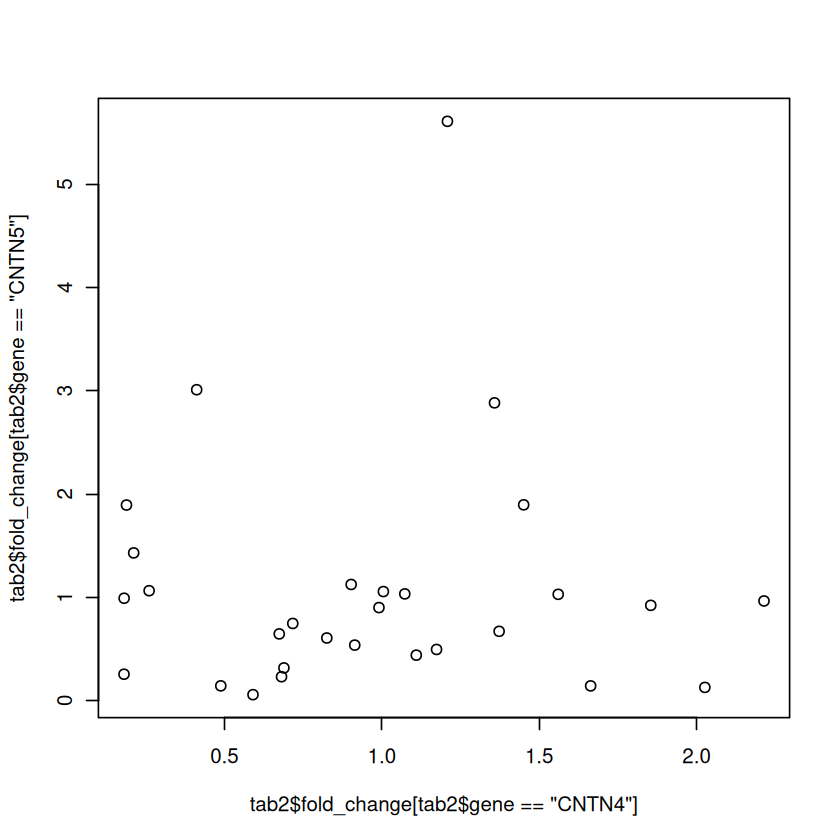

In [28]:
plot(tab2$fold_change[tab2$gene=='CNTN4'], tab2$fold_change[tab2$gene=='CNTN5'])

In [16]:
top_markers1[top_markers1$gene=='NCAM2',]

group,cell_type,gene,fold_change,auroc,log_fdr,population_size,population_fraction,average_expression,se_expression,detection_rate,fold_change_detection,precision,recall,rank
<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
all,1,NCAM2,1.759473,0.6869645,-111.52058,576,0.060421693,2326.696,82.17763,0.8958333,1.104190,0.066306862,0.8958333,41
all,10,NCAM2,3.886919,0.9232129,-447.76986,441,0.046260359,4743.538,95.34748,0.9931973,1.229312,0.056283732,0.9931973,4
all,14,NCAM2,3.151585,0.8828315,-213.85621,253,0.026539389,4124.165,125.20915,1.0000000,1.232281,0.032510923,1.0000000,6
all,19,NCAM2,3.261900,0.8927315,-191.90885,215,0.022553236,4293.292,150.51590,1.0000000,1.231115,0.027627859,1.0000000,3
all,20,NCAM2,2.726108,0.8025595,-124.83764,237,0.024861009,3615.797,250.02683,0.9915612,1.221081,0.030197893,0.9915612,24
all,21,NCAM2,2.516446,0.7304592,-48.95404,161,0.016888702,3393.956,255.68080,0.9440994,1.159450,0.019532254,0.9440994,79
all,28,NCAM2,2.275556,0.7762812,-17.08077,40,0.004195951,3130.832,343.98192,0.9750000,1.195121,0.005011565,0.9750000,64


In [48]:
combos = rbind(rep(ctypes2, each = length(ctypes3)), rep(ctypes3, length(ctypes2)))
dim(combos)
combos[1:2,1:4]

[1]   2 841

0,0,0,0
0,1,10,11


In [49]:
newdf = data.frame(cluster1 = combos[1,], cluster2 = combos[2,],
                  shared = NA, paralog1 = NA, paralog2 = NA)
pb = txtProgressBar(min = 0, max = dim(combos)[2], initial = 0)

for(ii in 1:dim(combos)[2]){
    ctype1 = combos[1,ii]
    ctype2 = combos[2,ii]
    m1 = top_markers1$gene[top_markers1$cell_type==ctype1]
    m2 = top_markers2$gene[top_markers2$cell_type==ctype2]
      
    temp = intersect(m1, m2)
    
    if(length(temp)){
        newdf$shared[ii] = length(temp)
        rem_genes1 = setdiff(m1, temp)
        rem_genes2 = setdiff(m2, temp)
    }else{
        rem_genes1 = m1
        rem_genes2 = m2
    }
    
    if(length(rem_genes1)){
        list1 = get_paralog_count(rem_genes1, m2, paralog_df1)
        newdf$paralog1[ii] = sum(list1[,2]>0)   # genes in cluster 1 are paralogs of markers in cluster 2; avoid double-counting
    }
    if(length(rem_genes2)){
        list2 = get_paralog_count(rem_genes2, m1, paralog_df2)
        newdf$paralog2[ii] = sum(list2[,2]>0)
    }
    
    setTxtProgressBar(pb, ii)
}

newdf$paralogs = rowMeans(newdf[,4:5], na.rm = T)
newdf[1:5,]

path_to_save = paste0('/vault/suresh/consensus_interneuron_taxonomy/', currstudy, '/')
write.table(newdf, file = paste0(path_to_save, sp1, '_', sp2, '_', currstudy, '_marker_paralogs_biomart.csv'), 
            sep = ',', row.names = F, col.names = T, quote = F)

,cluster1,cluster2,shared,paralog1,paralog2,paralogs
,<int>,<int>,<int>,<int>,<int>,<dbl>
1,0,0,62,11,6,8.5
2,0,1,19,20,17,18.5
3,0,10,19,24,23,23.5
4,0,11,11,20,20,20.0
5,0,12,26,18,17,17.5


In [20]:
# take 1 value per pair of cell types? take avgs for boxplots
# ancestral Sncg cluster - 17 in Sestan, 20 in Caglayan

# newdf = read.delim('human_chimp_marker_paralogs_biomart.csv', sep = ',')
newdf[newdf[,1]=='17',]

,cluster1,cluster2,shared,paralog1,paralog2,paralogs
,<int>,<int>,<int>,<int>,<int>,<dbl>
235,17,0,1,13,10,11.5
236,17,1,8,11,16,13.5
237,17,10,28,16,21,18.5
238,17,11,7,13,16,14.5
239,17,12,25,12,14,13.0
240,17,13,5,23,30,26.5
241,17,14,11,17,19,18.0
242,17,15,14,23,16,19.5
243,17,16,25,18,17,17.5


Warning message in cor.test.default(newdf$shared, newdf$paralogs, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  newdf$shared and newdf$paralogs
S = 67859037, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.3357178 


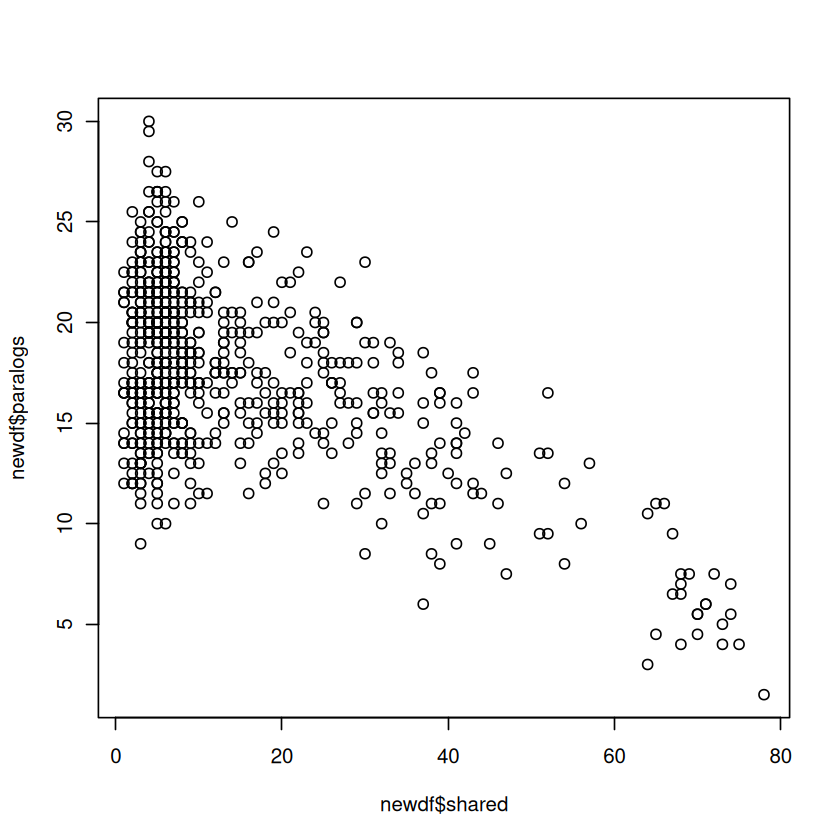

In [15]:
plot(newdf$shared, newdf$paralogs)
cor.test(newdf$shared, newdf$paralogs, method = 'spearman')